# Tesla Sales, Deliveries, and Forecasting



## 1. Objective

The dataset tracks Tesla metrics across `Year`, `Month`, `Region`, and `Model`, along with operational and market variables such as:
- `Estimated_Deliveries`
- `Production_Units`
- `Avg_Price_USD`
- `Battery_Capacity_kWh`
- `Range_km`
- `CO2_Saved_tons`
- `Charging_Stations`

We solve two related machine learning tasks:
1. Predict `Estimated_Deliveries` as a sales and demand regression problem.
2. Predict `Avg_Price_USD` as a price regression problem.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, accuracy_score, recall_score, f1_score, precision_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

from statsmodels.tsa.statespace.sarimax import SARIMAX

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 60)

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5


## 2. Load and Understand the Dataset


In [2]:
DATA_PATH = Path("tesla_deliveries_dataset_2015_2025.csv")
df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
display(df.head())
display(df.info())


Rows: 2,640
Columns: 12


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


None

In [3]:
summary = df.describe(include="all").T
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
})

display(summary)
display(missing)
print("Duplicate rows:", df.duplicated().sum())
print("Year range:", df["Year"].min(), "to", df["Year"].max())
print("Regions:", sorted(df["Region"].unique()))
print("Models:", sorted(df["Model"].unique()))
print("Source types:", sorted(df["Source_Type"].unique()))


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,2640.0,NaN,NaN,NaN,2020.0,3.162877,2015.0,2017.0,2020.0,2023.0,2025.0
Month,2640.0,NaN,NaN,NaN,6.5,3.452707,1.0,3.75,6.5,9.25,12.0
Region,2640,4,Europe,660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,2640,5,Model S,528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estimated_Deliveries,2640.0,NaN,NaN,NaN,9922.199621,3935.950093,48.0,7292.0,9857.0,12510.25,25704.0
Production_Units,2640.0,NaN,NaN,NaN,10655.847348,4260.600858,50.0,7828.25,10546.5,13469.0,28939.0
Avg_Price_USD,2640.0,NaN,NaN,NaN,84907.34033,20123.258036,50003.7,67726.365,85058.51,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,NaN,NaN,NaN,87.05947,20.836265,60.0,75.0,82.0,100.0,120.0
Range_km,2640.0,NaN,NaN,NaN,500.257576,120.868549,330.0,418.0,470.0,586.25,719.0
CO2_Saved_tons,2640.0,NaN,NaN,NaN,744.076989,353.221224,3.07,499.62,699.515,943.765,2548.55


,missing_count,missing_pct
Year,0,0.0
Month,0,0.0
Region,0,0.0
Model,0,0.0
Estimated_Deliveries,0,0.0
Production_Units,0,0.0
Avg_Price_USD,0,0.0
Battery_Capacity_kWh,0,0.0
Range_km,0,0.0
CO2_Saved_tons,0,0.0


Duplicate rows: 0
Year range: 2015 to 2025
Regions: ['Asia', 'Europe', 'Middle East', 'North America']
Models: ['Cybertruck', 'Model 3', 'Model S', 'Model X', 'Model Y']
Source types: ['Estimated (Region)', 'Interpolated (Month)', 'Official (Quarter)']


### Initial observations

Before any modeling, this dataset already tells us a few important things:
- It is fully structured with no missing values in the raw file.
- It is naturally panel data: each row belongs to a `(year, month, region, model)` slice.
- It mixes sales, production, technology, sustainability, and infrastructure variables.
- Because time is built into the data, random train-test splitting would be inappropriate.


## 3. Preprocessing and Validation

The raw file is already clean, but robust ML work still needs defensive preprocessing. We:
- standardize column names
- remove duplicates
- validate month values
- create a proper monthly timestamp
- sort chronologically for time-aware analysis


In [4]:
clean = df.copy()
clean.columns = clean.columns.str.strip()
clean = clean.drop_duplicates().reset_index(drop=True)

required_columns = [
    "Year", "Month", "Region", "Model", "Estimated_Deliveries", "Production_Units",
    "Avg_Price_USD", "Battery_Capacity_kWh", "Range_km", "CO2_Saved_tons",
    "Source_Type", "Charging_Stations"
]

missing_required = sorted(set(required_columns) - set(clean.columns))
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

if not clean["Month"].between(1, 12).all():
    raise ValueError("Month values must be between 1 and 12.")

clean["Date"] = pd.to_datetime(dict(year=clean["Year"], month=clean["Month"], day=1))
clean = clean.sort_values(["Date", "Region", "Model"]).reset_index(drop=True)

display(clean.head())
print("Date coverage:", clean["Date"].min().date(), "to", clean["Date"].max().date())


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2015,1,Asia,Cybertruck,11325,11887,54449.08,60,339,575.88,Estimated (Region),6902,2015-01-01
1,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01
2,2015,1,Asia,Model S,9537,10093,68994.43,82,484,692.39,Official (Quarter),7281,2015-01-01
3,2015,1,Asia,Model X,7292,7298,107082.30,120,702,767.85,Estimated (Region),11748,2015-01-01
4,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01


Date coverage: 2015-01-01 to 2025-12-01


## 4. Exploratory Data Analysis

To make the assignment stand out, the EDA is broader than a minimal classroom workflow. It combines:
- time-based trend analysis
- region and model composition
- seasonality
- distribution analysis
- operational relationships such as production versus deliveries
- sustainability and charging-infrastructure context

The EDA directions were inspired by the two reference notebooks, but consolidated here to avoid repeating the same view twice.


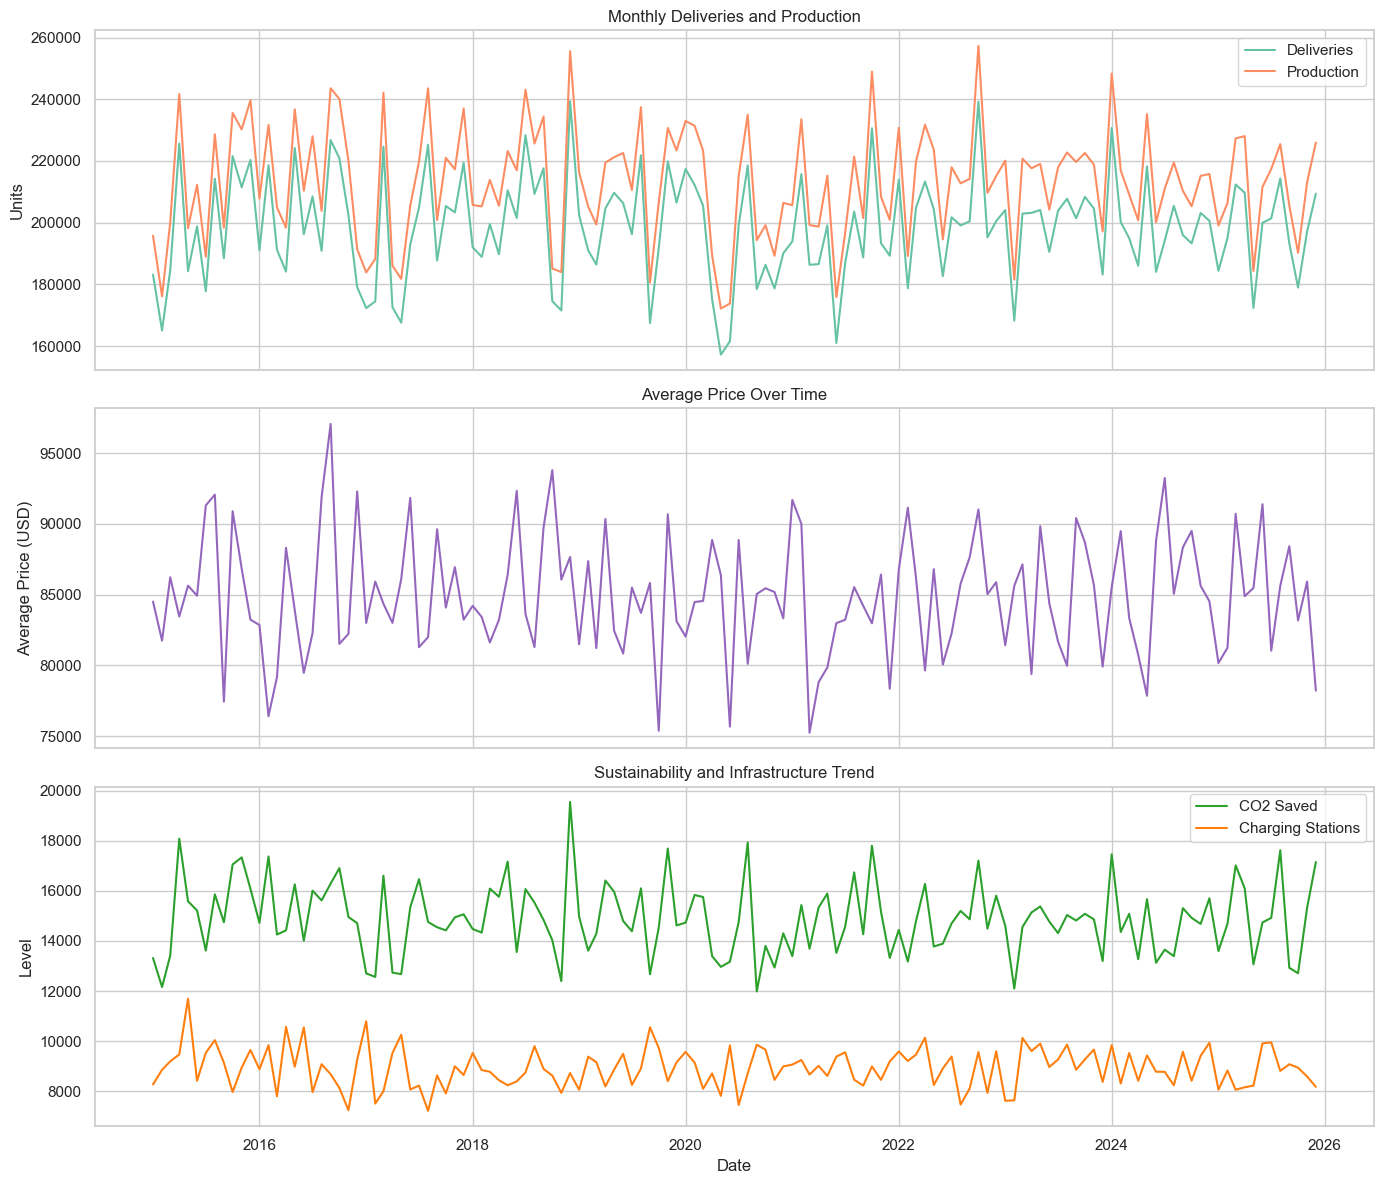

In [5]:
monthly = clean.groupby("Date", as_index=False).agg(
    Estimated_Deliveries=("Estimated_Deliveries", "sum"),
    Production_Units=("Production_Units", "sum"),
    Avg_Price_USD=("Avg_Price_USD", "mean"),
    Charging_Stations=("Charging_Stations", "mean"),
    CO2_Saved_tons=("CO2_Saved_tons", "sum")
)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
sns.lineplot(data=monthly, x="Date", y="Estimated_Deliveries", ax=axes[0], label="Deliveries")
sns.lineplot(data=monthly, x="Date", y="Production_Units", ax=axes[0], label="Production")
axes[0].set_title("Monthly Deliveries and Production")
axes[0].set_ylabel("Units")

sns.lineplot(data=monthly, x="Date", y="Avg_Price_USD", ax=axes[1], color="tab:purple")
axes[1].set_title("Average Price Over Time")
axes[1].set_ylabel("Average Price (USD)")

sns.lineplot(data=monthly, x="Date", y="CO2_Saved_tons", ax=axes[2], color="tab:green", label="CO2 Saved")
sns.lineplot(data=monthly, x="Date", y="Charging_Stations", ax=axes[2], color="tab:orange", label="Charging Stations")
axes[2].set_title("Sustainability and Infrastructure Trend")
axes[2].set_ylabel("Level")
plt.tight_layout()


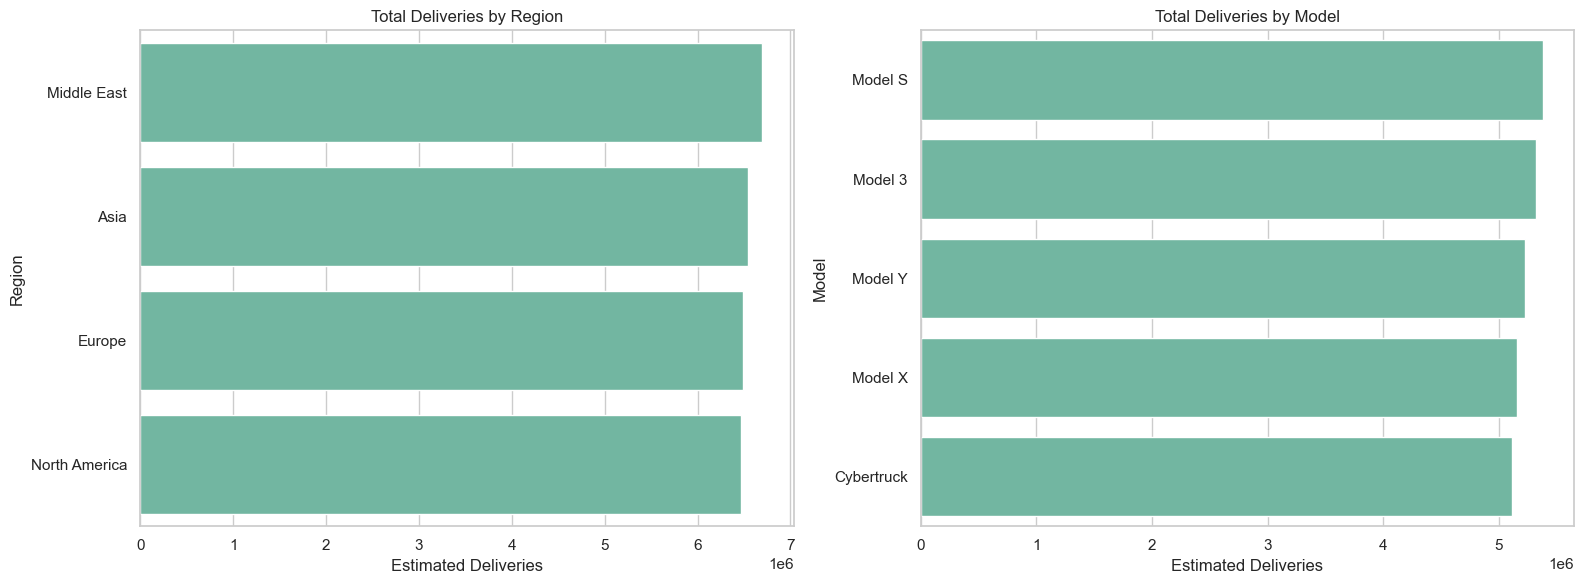

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_summary = clean.groupby("Region", as_index=False)["Estimated_Deliveries"].sum().sort_values("Estimated_Deliveries", ascending=False)
model_summary = clean.groupby("Model", as_index=False)["Estimated_Deliveries"].sum().sort_values("Estimated_Deliveries", ascending=False)

sns.barplot(data=region_summary, x="Estimated_Deliveries", y="Region", ax=axes[0])
axes[0].set_title("Total Deliveries by Region")
axes[0].set_xlabel("Estimated Deliveries")

sns.barplot(data=model_summary, x="Estimated_Deliveries", y="Model", ax=axes[1])
axes[1].set_title("Total Deliveries by Model")
axes[1].set_xlabel("Estimated Deliveries")
plt.tight_layout()


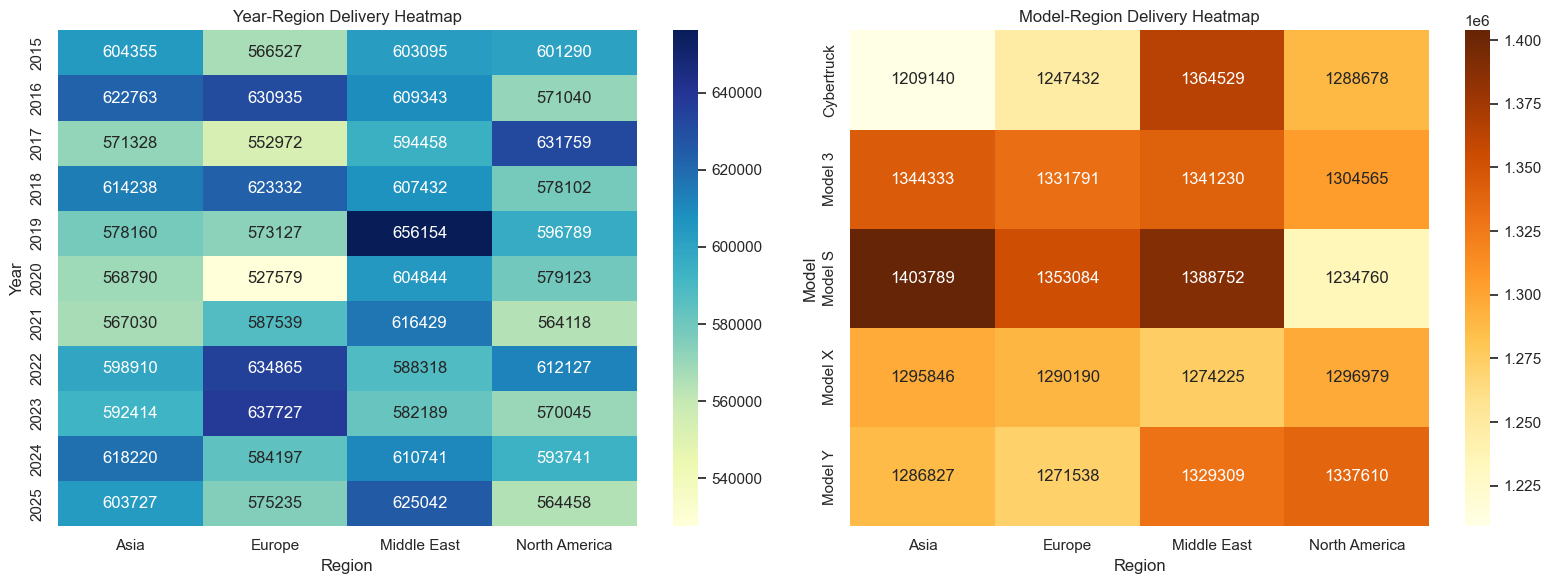

In [7]:
region_year = clean.pivot_table(index="Year", columns="Region", values="Estimated_Deliveries", aggfunc="sum")
model_region = clean.pivot_table(index="Model", columns="Region", values="Estimated_Deliveries", aggfunc="sum")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(region_year, annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Year-Region Delivery Heatmap")

sns.heatmap(model_region, annot=True, fmt=".0f", cmap="YlOrBr", ax=axes[1])
axes[1].set_title("Model-Region Delivery Heatmap")
plt.tight_layout()


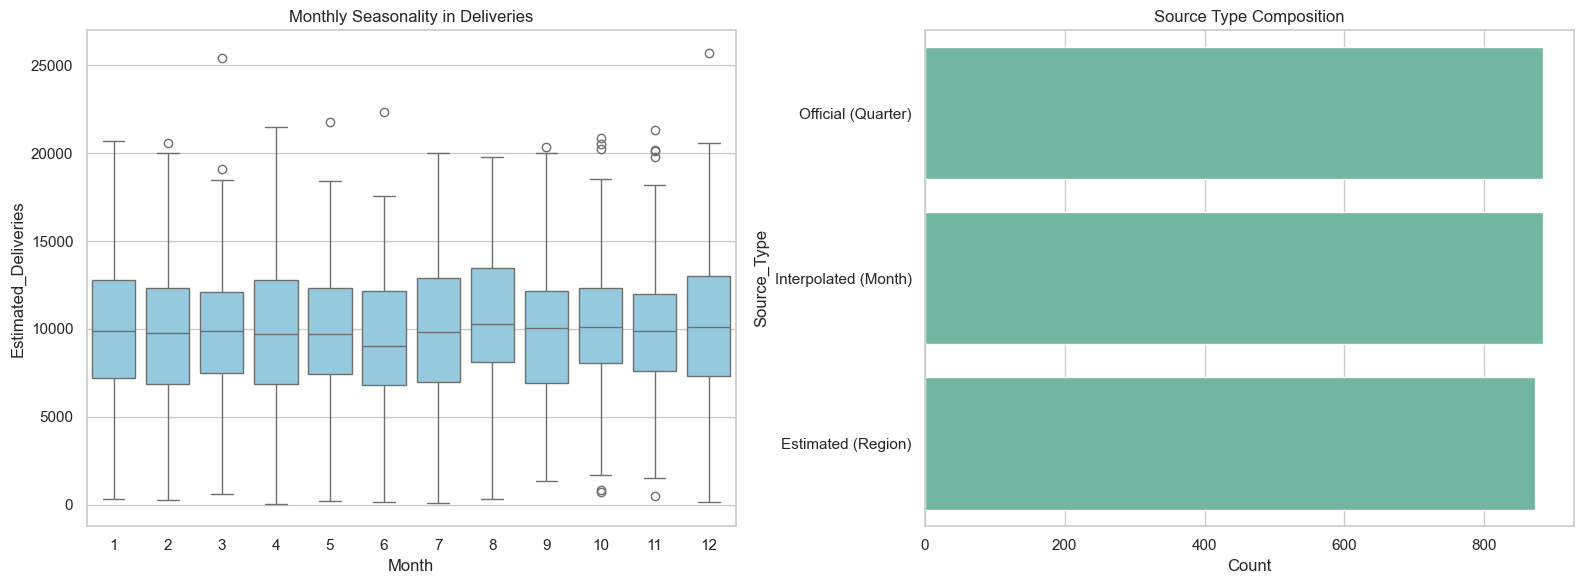

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=clean, x="Month", y="Estimated_Deliveries", ax=axes[0], color="skyblue")
axes[0].set_title("Monthly Seasonality in Deliveries")

source_counts = clean["Source_Type"].value_counts().reset_index()
source_counts.columns = ["Source_Type", "Count"]
sns.barplot(data=source_counts, x="Count", y="Source_Type", ax=axes[1])
axes[1].set_title("Source Type Composition")
plt.tight_layout()


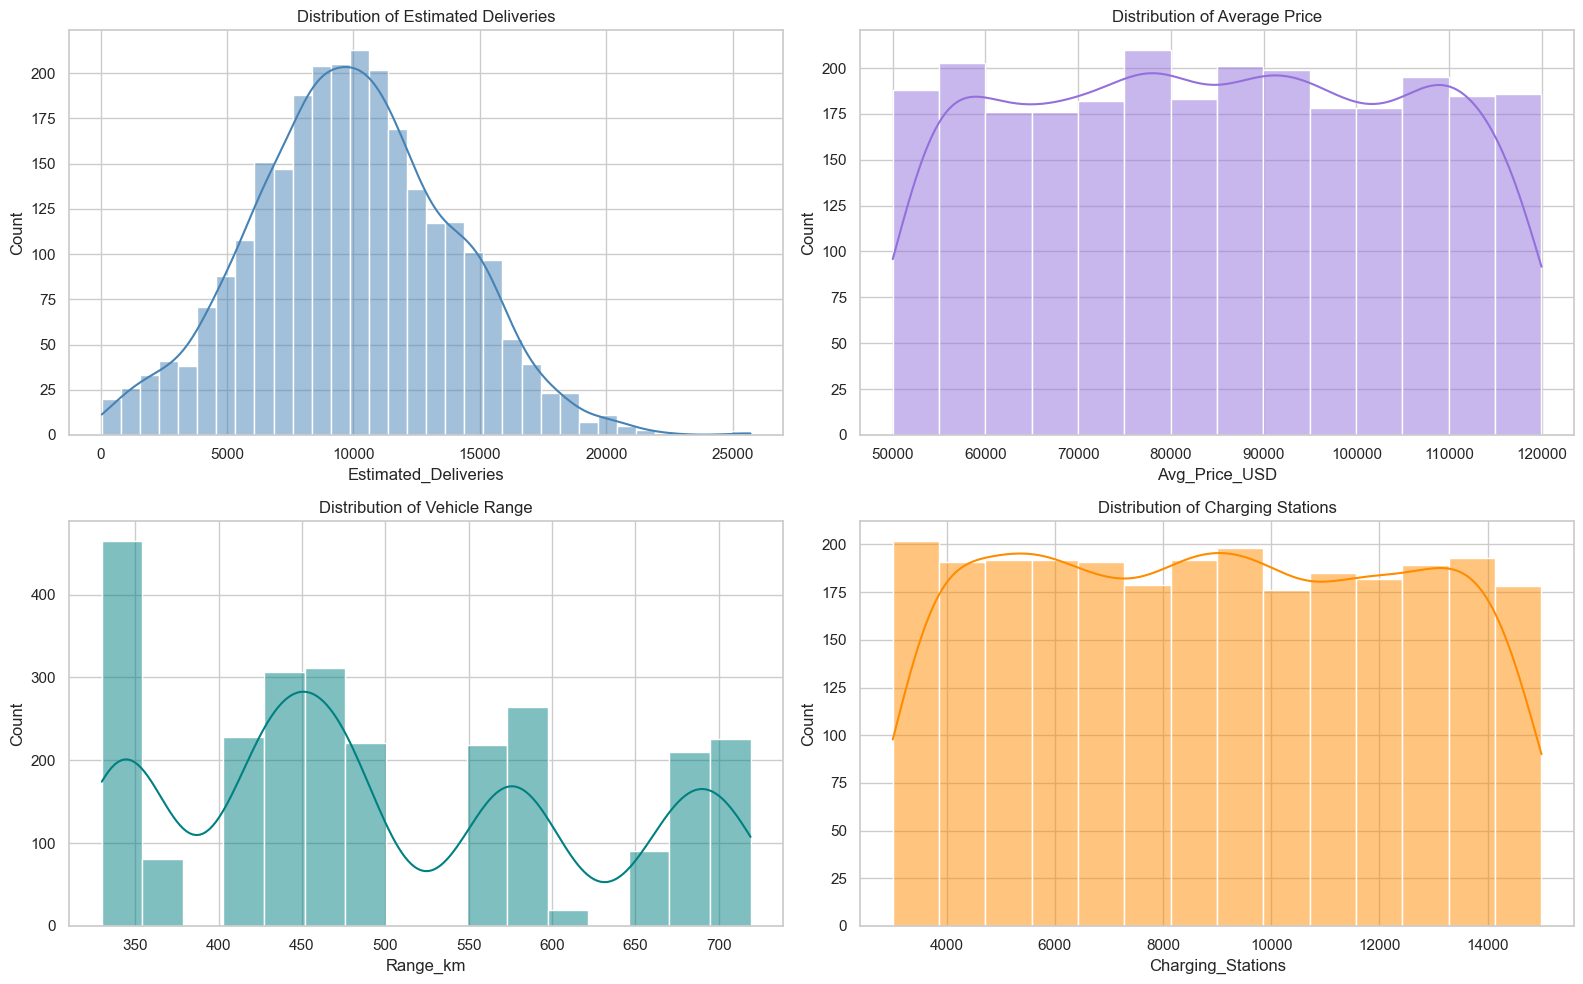

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.histplot(clean["Estimated_Deliveries"], kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Distribution of Estimated Deliveries")

sns.histplot(clean["Avg_Price_USD"], kde=True, ax=axes[0, 1], color="mediumpurple")
axes[0, 1].set_title("Distribution of Average Price")

sns.histplot(clean["Range_km"], kde=True, ax=axes[1, 0], color="teal")
axes[1, 0].set_title("Distribution of Vehicle Range")

sns.histplot(clean["Charging_Stations"], kde=True, ax=axes[1, 1], color="darkorange")
axes[1, 1].set_title("Distribution of Charging Stations")
plt.tight_layout()


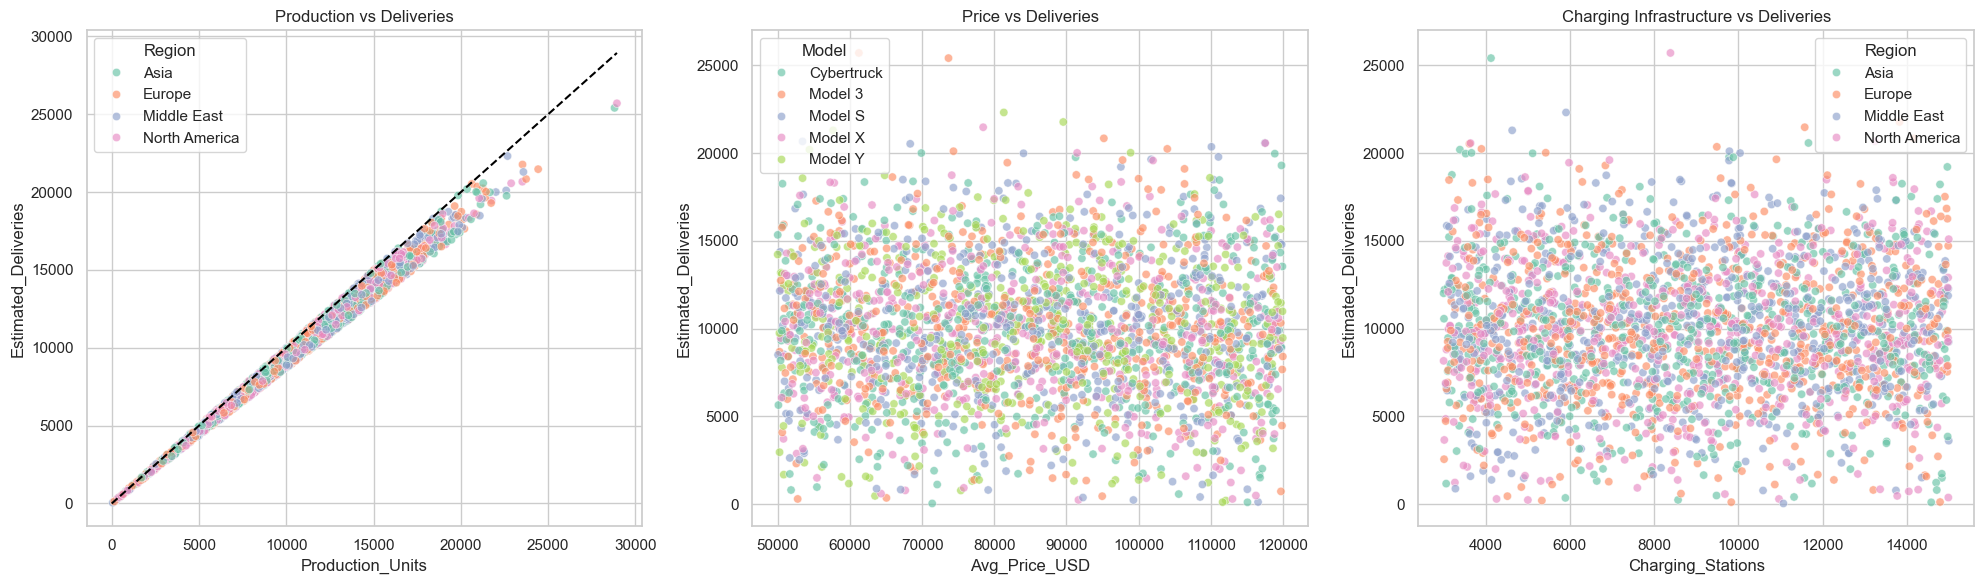

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

max_value = max(clean["Production_Units"].max(), clean["Estimated_Deliveries"].max())
sns.scatterplot(data=clean, x="Production_Units", y="Estimated_Deliveries", hue="Region", alpha=0.65, ax=axes[0])
axes[0].plot([0, max_value], [0, max_value], linestyle="--", color="black")
axes[0].set_title("Production vs Deliveries")

sns.scatterplot(data=clean, x="Avg_Price_USD", y="Estimated_Deliveries", hue="Model", alpha=0.65, ax=axes[1])
axes[1].set_title("Price vs Deliveries")

sns.scatterplot(data=clean, x="Charging_Stations", y="Estimated_Deliveries", hue="Region", alpha=0.65, ax=axes[2])
axes[2].set_title("Charging Infrastructure vs Deliveries")
plt.tight_layout()


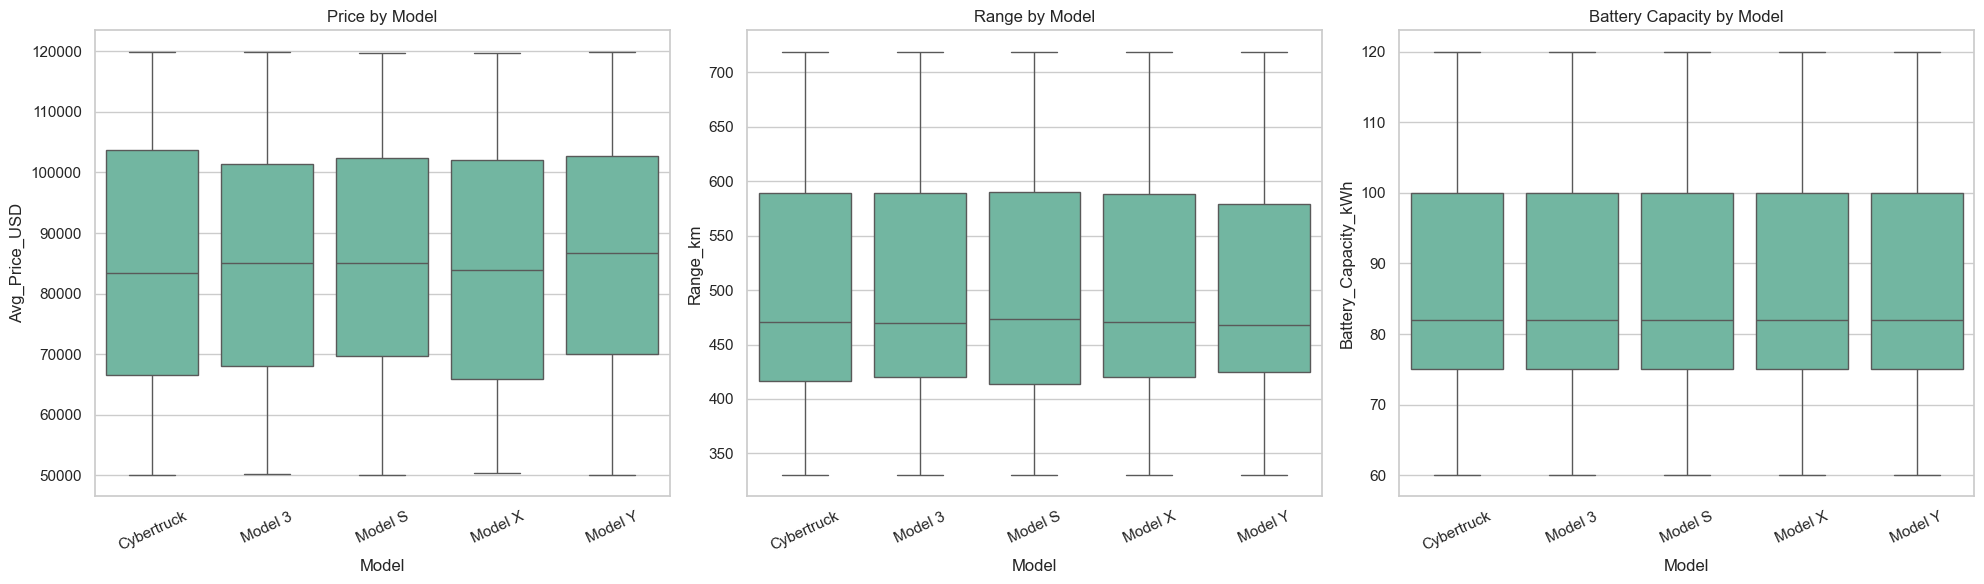

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.boxplot(data=clean, x="Model", y="Avg_Price_USD", ax=axes[0])
axes[0].set_title("Price by Model")
axes[0].tick_params(axis="x", rotation=25)

sns.boxplot(data=clean, x="Model", y="Range_km", ax=axes[1])
axes[1].set_title("Range by Model")
axes[1].tick_params(axis="x", rotation=25)

sns.boxplot(data=clean, x="Model", y="Battery_Capacity_kWh", ax=axes[2])
axes[2].set_title("Battery Capacity by Model")
axes[2].tick_params(axis="x", rotation=25)
plt.tight_layout()


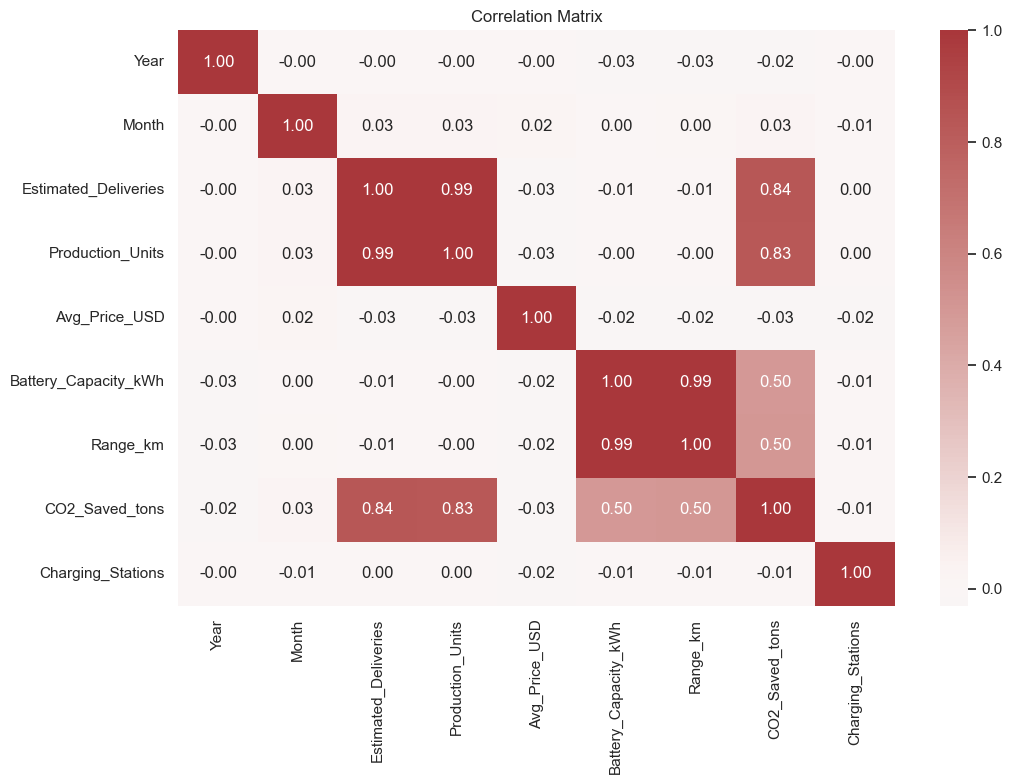

In [12]:
corr = clean.select_dtypes(include=np.number).corr()
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()


In [13]:
eda_snapshot = {
    "Top region by total deliveries": clean.groupby("Region")["Estimated_Deliveries"].sum().sort_values(ascending=False).index[0],
    "Top model by total deliveries": clean.groupby("Model")["Estimated_Deliveries"].sum().sort_values(ascending=False).index[0],
    "Strongest numeric correlation with deliveries": clean.select_dtypes(include=np.number).corr()["Estimated_Deliveries"].drop("Estimated_Deliveries").sort_values(ascending=False).index[0],
    "Most active month by total deliveries": int(clean.groupby("Month")["Estimated_Deliveries"].sum().sort_values(ascending=False).index[0]),
}

display(pd.DataFrame.from_dict(eda_snapshot, orient="index", columns=["Insight"]))


,Insight
Top region by total deliveries,Middle East
Top model by total deliveries,Model S
Strongest numeric correlation with deliveries,Production_Units
Most active month by total deliveries,8


### EDA interpretation

The exploratory analysis supports a few strong hypotheses:

- **Production and deliveries move together closely**, which is exactly what we would expect in a supply-constrained EV business.
- **Regional performance is fairly balanced**, but some regions still edge out others in cumulative deliveries.
- **Model mix matters**, because price, range, and battery profiles differ across Tesla models.
- **Seasonality exists**, so month-level encoding is justified.
- **Charging infrastructure and CO2 savings provide context**, but their predictive relationship is weaker than raw production volume.

This is the point where EDA becomes useful for modeling: it tells us which variables are likely to contribute signal and which ones should be treated more cautiously.


## 5. Feature Engineering

Feature engineering was designed around two principles:
1. capture time structure and business logic
2. avoid target leakage

Created features:
- `Quarter`, `Month_Sin`, `Month_Cos`, `Year_Index` for seasonality and trend
- `Price_per_km_Range`, `Price_per_kWh` for product-value framing
- `Deliveries_Lag_1`, `Deliveries_Lag_3`, `Deliveries_Rolling_3` for demand momentum
- `Price_Lag_1`, `Price_Rolling_3` for price trend memory

Leakage warning:
- `Production_Gap`, `Production_to_Delivery_Ratio`, and `CO2_per_Delivery` all use the current delivery target.
- For price prediction, any feature built directly from the current price target must be excluded.

These leakage-prone features are still useful for EDA, but they are intentionally removed from the supervised model feature sets.


In [14]:
def add_features(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy().sort_values(["Region", "Model", "Date"])
    out["Quarter"] = out["Date"].dt.quarter
    out["Month_Sin"] = np.sin(2 * np.pi * out["Month"] / 12)
    out["Month_Cos"] = np.cos(2 * np.pi * out["Month"] / 12)
    out["Year_Index"] = out["Year"] - out["Year"].min()

    # Useful for EDA but not always safe for supervised targets.
    out["Production_Gap"] = out["Production_Units"] - out["Estimated_Deliveries"]
    out["Production_to_Delivery_Ratio"] = out["Production_Units"] / out["Estimated_Deliveries"].replace(0, np.nan)
    out["Price_per_km_Range"] = out["Avg_Price_USD"] / out["Range_km"].replace(0, np.nan)
    out["Price_per_kWh"] = out["Avg_Price_USD"] / out["Battery_Capacity_kWh"].replace(0, np.nan)
    out["CO2_per_Delivery"] = out["CO2_Saved_tons"] / out["Estimated_Deliveries"].replace(0, np.nan)

    group_cols = ["Region", "Model"]
    out["Deliveries_Lag_1"] = out.groupby(group_cols)["Estimated_Deliveries"].shift(1)
    out["Deliveries_Lag_3"] = out.groupby(group_cols)["Estimated_Deliveries"].shift(3)
    out["Deliveries_Rolling_3"] = out.groupby(group_cols)["Estimated_Deliveries"].transform(
        lambda s: s.shift(1).rolling(3).mean()
    )
    out["Price_Lag_1"] = out.groupby(group_cols)["Avg_Price_USD"].shift(1)
    out["Price_Rolling_3"] = out.groupby(group_cols)["Avg_Price_USD"].transform(
        lambda s: s.shift(1).rolling(3).mean()
    )
    return out

featured = add_features(clean)
display(featured.head(10))


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Month_Sin,Month_Cos,Year_Index,Production_Gap,Production_to_Delivery_Ratio,Price_per_km_Range,Price_per_kWh,CO2_per_Delivery,Deliveries_Lag_1,Deliveries_Lag_3,Deliveries_Rolling_3,Price_Lag_1,Price_Rolling_3
0,2015,1,Asia,Cybertruck,11325,11887,54449.08,60,339,575.88,Estimated (Region),6902,2015-01-01,1,5.000000e-01,8.660254e-01,0,562,1.049625,160.616755,907.484667,0.050850,NaN,NaN,NaN,NaN,NaN
20,2015,2,Asia,Cybertruck,13254,14878,88864.06,75,432,858.86,Estimated (Region),5902,2015-02-01,1,8.660254e-01,5.000000e-01,0,1624,1.122529,205.703843,1184.854133,0.064800,11325.0,NaN,NaN,54449.08,NaN
40,2015,3,Asia,Cybertruck,10257,11441,65107.47,100,581,893.90,Interpolated (Month),4024,2015-03-01,1,1.000000e+00,6.123234e-17,0,1184,1.115433,112.061050,651.074700,0.087150,13254.0,NaN,NaN,88864.06,NaN
60,2015,4,Asia,Cybertruck,15221,15951,112686.63,60,341,778.55,Estimated (Region),3130,2015-04-01,2,8.660254e-01,-5.000000e-01,0,730,1.047960,330.459326,1878.110500,0.051150,10257.0,11325.0,11612.000000,65107.47,69473.536667
80,2015,5,Asia,Cybertruck,6406,7281,107577.61,75,448,430.48,Interpolated (Month),11708,2015-05-01,2,5.000000e-01,-8.660254e-01,0,875,1.136591,240.128594,1434.368133,0.067200,15221.0,13254.0,12910.666667,112686.63,88886.053333
100,2015,6,Asia,Cybertruck,7201,8144,114461.07,75,414,447.18,Estimated (Region),6322,2015-06-01,2,1.224647e-16,-1.000000e+00,0,943,1.130954,276.476014,1526.147600,0.062100,6406.0,10257.0,10628.000000,107577.61,95123.903333
120,2015,7,Asia,Cybertruck,113,118,115067.04,120,709,12.02,Interpolated (Month),14580,2015-07-01,3,-5.000000e-01,-8.660254e-01,0,5,1.044248,162.294838,958.892000,0.106372,7201.0,15221.0,9609.333333,114461.07,111575.103333
140,2015,8,Asia,Cybertruck,10222,11128,77930.19,60,331,507.52,Official (Quarter),7022,2015-08-01,3,-8.660254e-01,-5.000000e-01,0,906,1.088632,235.438640,1298.836500,0.049650,113.0,6406.0,4573.333333,115067.04,112368.573333
160,2015,9,Asia,Cybertruck,10844,12086,59807.92,60,356,579.07,Interpolated (Month),8849,2015-09-01,3,-1.000000e+00,-1.836970e-16,0,1242,1.114533,167.999775,996.798667,0.053400,10222.0,7201.0,5845.333333,77930.19,102486.100000
180,2015,10,Asia,Cybertruck,5675,6461,117974.08,120,716,609.49,Estimated (Region),8690,2015-10-01,4,-8.660254e-01,5.000000e-01,0,786,1.138502,164.768268,983.117333,0.107399,10844.0,113.0,7059.666667,59807.92,84268.383333


## 6. Train-Test Strategy

This is time-indexed data, so the split must preserve chronology. We train on records before `2024-01-01` and test on `2024-2025`.

This simulates a realistic deployment setting:
- the model only sees the past
- the evaluation happens on the future


In [15]:
model_data = featured.dropna().copy()

train = model_data[model_data["Date"] < "2024-01-01"].copy()
test = model_data[model_data["Date"] >= "2024-01-01"].copy()

print(f"Training rows: {len(train):,}")
print(f"Test rows: {len(test):,}")
print(f"Train period: {train['Date'].min().date()} to {train['Date'].max().date()}")
print(f"Test period: {test['Date'].min().date()} to {test['Date'].max().date()}")


Training rows: 2,100
Test rows: 480
Train period: 2015-04-01 to 2023-12-01
Test period: 2024-01-01 to 2025-12-01


## 7. Model Selection: Which Models and Why

We compare multiple regressors instead of assuming a single best family.

Chosen models:
- **Linear Regression**: the most fundamental linear baseline
- **Ridge Regression**: a transparent linear baseline with regularization
- **Random Forest Regressor**: strong for nonlinear interactions and robust to mixed signals
- **Gradient Boosting Regressor**: useful when relationships are nonlinear but smoother than bagged trees
- **XGBoost Regressor**: a high-performing boosting method that often works well on structured tabular data

Why this mix matters:
- linear vs nonlinear comparison
- interpretable baseline vs high-capacity learners
- robustness check across model families
- better assignment quality because the choice is reasoned, not arbitrary


In [16]:
delivery_target = "Estimated_Deliveries"
price_target = "Avg_Price_USD"

categorical_features = ["Region", "Model", "Source_Type"]

delivery_features = [
    "Year", "Month", "Quarter", "Month_Sin", "Month_Cos", "Year_Index",
    "Region", "Model", "Source_Type", "Production_Units", "Battery_Capacity_kWh",
    "Range_km", "CO2_Saved_tons", "Charging_Stations", "Price_per_km_Range",
    "Price_per_kWh", "Deliveries_Lag_1", "Deliveries_Lag_3", "Deliveries_Rolling_3",
    "Price_Lag_1", "Price_Rolling_3", "Avg_Price_USD"
]

price_features = [
    "Year", "Month", "Quarter", "Month_Sin", "Month_Cos", "Year_Index",
    "Region", "Model", "Source_Type", "Production_Units", "Battery_Capacity_kWh",
    "Range_km", "CO2_Saved_tons", "Charging_Stations", "Deliveries_Lag_1",
    "Deliveries_Lag_3", "Deliveries_Rolling_3", "Price_Lag_1", "Price_Rolling_3",
    "Estimated_Deliveries"
]

def make_preprocessor(feature_list):
    numeric = [c for c in feature_list if c not in categorical_features]
    categorical = [c for c in categorical_features if c in feature_list]
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                numeric,
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]),
                categorical,
            ),
        ]
    )

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return {
        "model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "MAPE": mean_absolute_percentage_error(y_test, preds),
        "Accuracy": accuracy_score(y_test > y_train.median(), preds > y_train.median()),
        "Recall": recall_score(y_test > y_train.median(), preds > y_train.median(), zero_division=0),
        "F1": f1_score(y_test > y_train.median(), preds > y_train.median(), zero_division=0),
        "Precision": precision_score(y_test > y_train.median(), preds > y_train.median(), zero_division=0),
        "RMSE": rmse(y_test, preds),
        "R2": r2_score(y_test, preds),
    }, preds


In [17]:
X_train_delivery = train[delivery_features]
X_test_delivery = test[delivery_features]
y_train_delivery = train[delivery_target]
y_test_delivery = test[delivery_target]

X_train_price = train[price_features]
X_test_price = test[price_features]
y_train_price = train[price_target]
y_test_price = test[price_target]

regressors = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

if HAS_XGBOOST:
    regressors["XGBoost"] = XGBRegressor(
        n_estimators=350,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )

delivery_results = []
for name, reg in regressors.items():
    pipeline = Pipeline([
        ("preprocess", make_preprocessor(delivery_features)),
        ("model", reg),
    ])
    result, _ = evaluate_model(
        name, pipeline,
        X_train_delivery, y_train_delivery,
        X_test_delivery, y_test_delivery
    )
    delivery_results.append(result)

delivery_results_df = pd.DataFrame(delivery_results).sort_values("RMSE")
display(delivery_results_df)


,model,MAE,MAPE,Accuracy,Recall,F1,Precision,RMSE,R2
4,XGBoost,285.629242,0.030455,0.972917,0.969565,0.971678,0.973799,350.574361,0.991150
1,Ridge,321.435924,0.038321,0.970833,0.969565,0.969565,0.969565,390.838439,0.989001
0,Linear Regression,322.000646,0.038215,0.970833,0.969565,0.969565,0.969565,391.126387,0.988985
3,Gradient Boosting,336.503530,0.034805,0.960417,0.956522,0.958606,0.960699,410.325347,0.987877
2,Random Forest,338.849639,0.034833,0.962500,0.956522,0.960699,0.964912,420.199323,0.987286


In [18]:
price_results = []
for name, reg in regressors.items():
    pipeline = Pipeline([
        ("preprocess", make_preprocessor(price_features)),
        ("model", reg),
    ])
    result, _ = evaluate_model(
        name, pipeline,
        X_train_price, y_train_price,
        X_test_price, y_test_price
    )
    price_results.append(result)

price_results_df = pd.DataFrame(price_results).sort_values("RMSE")
display(price_results_df)


,model,MAE,MAPE,Accuracy,Recall,F1,Precision,RMSE,R2
1,Ridge,17411.340198,0.220616,0.518750,0.342742,0.423940,0.555556,20156.259250,-0.011282
0,Linear Regression,17411.519109,0.220617,0.520833,0.346774,0.427861,0.558442,20156.810804,-0.011338
2,Random Forest,17447.118281,0.222534,0.506250,0.435484,0.476821,0.526829,20219.638278,-0.017652
3,Gradient Boosting,17594.317833,0.224075,0.508333,0.411290,0.463636,0.531250,20436.472880,-0.039596
4,XGBoost,17498.876403,0.223688,0.516667,0.475806,0.504274,0.536364,20595.606336,-0.055849


### Model comparison interpretation

Delivery prediction is expected to perform better than price prediction here because the dataset contains direct operational drivers of deliveries, especially production and lagged demand, while price appears to be less tightly explained by the available features.

That matters in an assignment setting because it shows judgment:
- a strong score is only meaningful if the feature design is leakage-safe
- a weaker score can still be a good result if it exposes a real limitation of the data


## 8. Hyperparameter Tuning

We tune the delivery Random Forest with `TimeSeriesSplit` so that every validation fold respects time ordering. This is more realistic than ordinary cross-validation for sequential data.


In [19]:
tuned_pipeline = Pipeline([
    ("preprocess", make_preprocessor(delivery_features)),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
])

param_distributions = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [None, 6, 10, 14, 18],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.7, 1.0],
}

tscv = TimeSeriesSplit(n_splits=5)
search = RandomizedSearchCV(
    tuned_pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train_delivery, y_train_delivery)
best_delivery_model = search.best_estimator_
tuned_preds = best_delivery_model.predict(X_test_delivery)

print("Best parameters:")
display(search.best_params_)

tuned_metrics = pd.DataFrame([{
    "MAE": mean_absolute_error(y_test_delivery, tuned_preds),
    "MAPE": mean_absolute_percentage_error(y_test_delivery, tuned_preds),
    "Accuracy": accuracy_score(y_test_delivery > y_train_delivery.median(), tuned_preds > y_train_delivery.median()),
    "Recall": recall_score(y_test_delivery > y_train_delivery.median(), tuned_preds > y_train_delivery.median(), zero_division=0),
    "F1": f1_score(y_test_delivery > y_train_delivery.median(), tuned_preds > y_train_delivery.median(), zero_division=0),
    "Precision": precision_score(y_test_delivery > y_train_delivery.median(), tuned_preds > y_train_delivery.median(), zero_division=0),
    "RMSE": rmse(y_test_delivery, tuned_preds),
    "R2": r2_score(y_test_delivery, tuned_preds),
}])
display(tuned_metrics)


Fitting 5 folds for each of 25 candidates, totalling 125 fits


Best parameters:


{'model__n_estimators': 500,
 'model__min_samples_split': 2,
 'model__min_samples_leaf': 2,
 'model__max_features': 0.7,
 'model__max_depth': None}

,MAE,MAPE,Accuracy,Recall,F1,Precision,RMSE,R2
0,300.03953,0.030439,0.964583,0.96087,0.962963,0.965066,377.547318,0.989736


,Date,Region,Model,Estimated_Deliveries,Predicted_Deliveries,Absolute_Error
2573,2025-09-01,Middle East,Model X,12995,14114.429222,1119.429222
2553,2025-08-01,Middle East,Model X,17242,16167.578060,1074.421940
2364,2024-11-01,Asia,Model Y,18216,17230.825240,985.174760
2211,2024-03-01,Middle East,Model 3,16656,15687.214908,968.785092
2510,2025-06-01,Middle East,Cybertruck,14633,13666.652424,966.347576
2532,2025-07-01,Middle East,Model S,17474,18434.532470,960.532470
2598,2025-10-01,North America,Model X,16033,15098.300424,934.699576
2523,2025-07-01,Asia,Model X,16163,17084.072592,921.072592
2303,2024-08-01,Asia,Model X,13506,12587.312569,918.687431
2168,2024-01-01,Europe,Model X,13567,14472.626578,905.626578


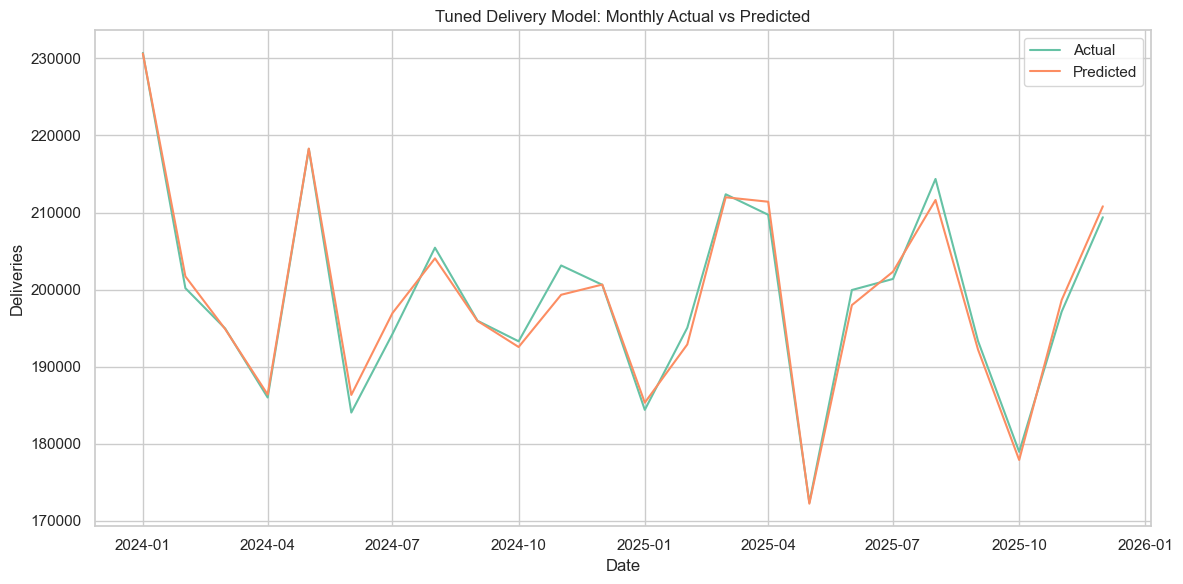

In [20]:
prediction_view = test[["Date", "Region", "Model", "Estimated_Deliveries"]].copy()
prediction_view["Predicted_Deliveries"] = tuned_preds
prediction_view["Absolute_Error"] = (
    prediction_view["Estimated_Deliveries"] - prediction_view["Predicted_Deliveries"]
).abs()

monthly_pred = prediction_view.groupby("Date", as_index=False).agg(
    Actual=("Estimated_Deliveries", "sum"),
    Predicted=("Predicted_Deliveries", "sum")
)

sns.lineplot(data=monthly_pred, x="Date", y="Actual", label="Actual")
sns.lineplot(data=monthly_pred, x="Date", y="Predicted", label="Predicted")
plt.title("Tuned Delivery Model: Monthly Actual vs Predicted")
plt.ylabel("Deliveries")
plt.tight_layout()

display(prediction_view.sort_values("Absolute_Error", ascending=False).head(10))


## 9. Feature Importance


,feature,importance
6,Production_Units,0.800784
9,CO2_Saved_tons,0.178973
8,Range_km,0.007387
7,Battery_Capacity_kWh,0.002816
16,Price_Lag_1,0.001199
15,Deliveries_Rolling_3,0.000957
11,Price_per_km_Range,0.000882
10,Charging_Stations,0.000860
13,Deliveries_Lag_1,0.000831
18,Avg_Price_USD,0.000796


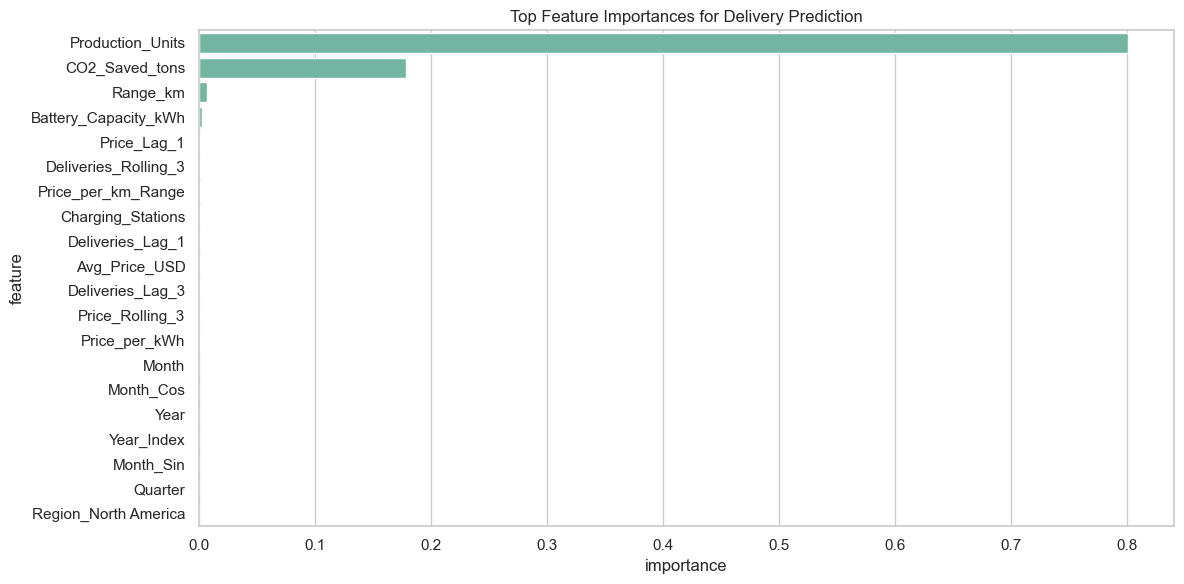

In [21]:
def get_feature_names(preprocess_step):
    names = []
    for transformer_name, transformer, columns in preprocess_step.transformers_:
        if transformer_name == "remainder" and transformer == "drop":
            continue
        if transformer_name == "num":
            names.extend(columns)
        elif transformer_name == "cat":
            encoder = transformer.named_steps["onehot"]
            names.extend(encoder.get_feature_names_out(columns))
    return names

if hasattr(best_delivery_model.named_steps["model"], "feature_importances_"):
    feature_names = get_feature_names(best_delivery_model.named_steps["preprocess"])
    importances = pd.DataFrame({
        "feature": feature_names,
        "importance": best_delivery_model.named_steps["model"].feature_importances_
    }).sort_values("importance", ascending=False).head(20)

    display(importances)
    sns.barplot(data=importances, x="importance", y="feature")
    plt.title("Top Feature Importances for Delivery Prediction")
    plt.tight_layout()
else:
    print("Selected model does not expose tree-based feature importances.")


### What the feature importances mean

Feature importance is not the same as causality, but it is still useful. If production volume dominates the ranking, that supports the operational intuition from EDA: Tesla deliveries are strongly anchored to production capacity. Lagged delivery features then add a momentum signal, while product and market variables refine the prediction.


## 10. Time Series Forecasting

The forecasting stage works on aggregate monthly deliveries. We use two approaches:
- **SARIMAX** for classical time-series structure with yearly seasonality
- **Lag-based Gradient Boosting** as an ML benchmark

This combination helps show both forecasting traditions: statistical sequence modeling and supervised tabular forecasting.


,MAE,RMSE
0,13435.590125,16570.112432


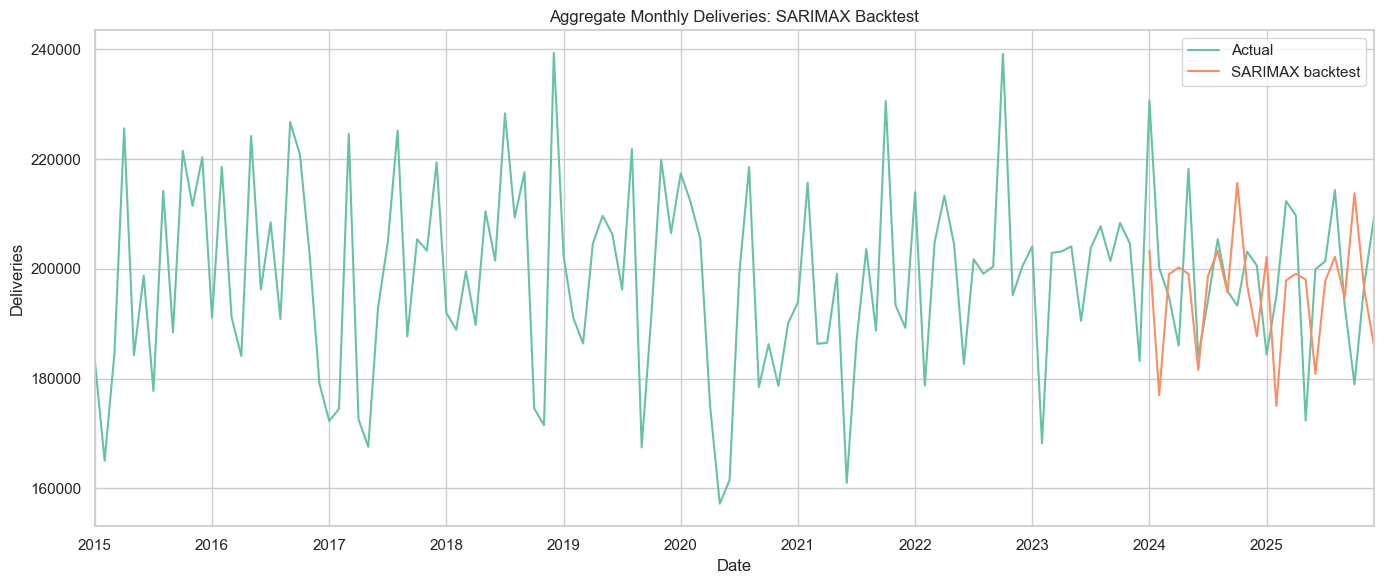

In [22]:
ts = monthly.set_index("Date")["Estimated_Deliveries"].asfreq("MS")
ts_train = ts.loc[:"2023-12-01"]
ts_test = ts.loc["2024-01-01":]

sarimax = SARIMAX(
    ts_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_result = sarimax.fit(disp=False)
sarimax_test_forecast = sarimax_result.get_forecast(steps=len(ts_test)).predicted_mean

sarimax_metrics = pd.DataFrame([{
    "MAE": mean_absolute_error(ts_test, sarimax_test_forecast),
    "RMSE": rmse(ts_test, sarimax_test_forecast),
}])
display(sarimax_metrics)

ax = ts.plot(label="Actual", figsize=(14, 6))
sarimax_test_forecast.plot(ax=ax, label="SARIMAX backtest")
ax.set_title("Aggregate Monthly Deliveries: SARIMAX Backtest")
ax.set_ylabel("Deliveries")
ax.legend()
plt.tight_layout()


,MAE,RMSE
0,11634.467622,15389.057001


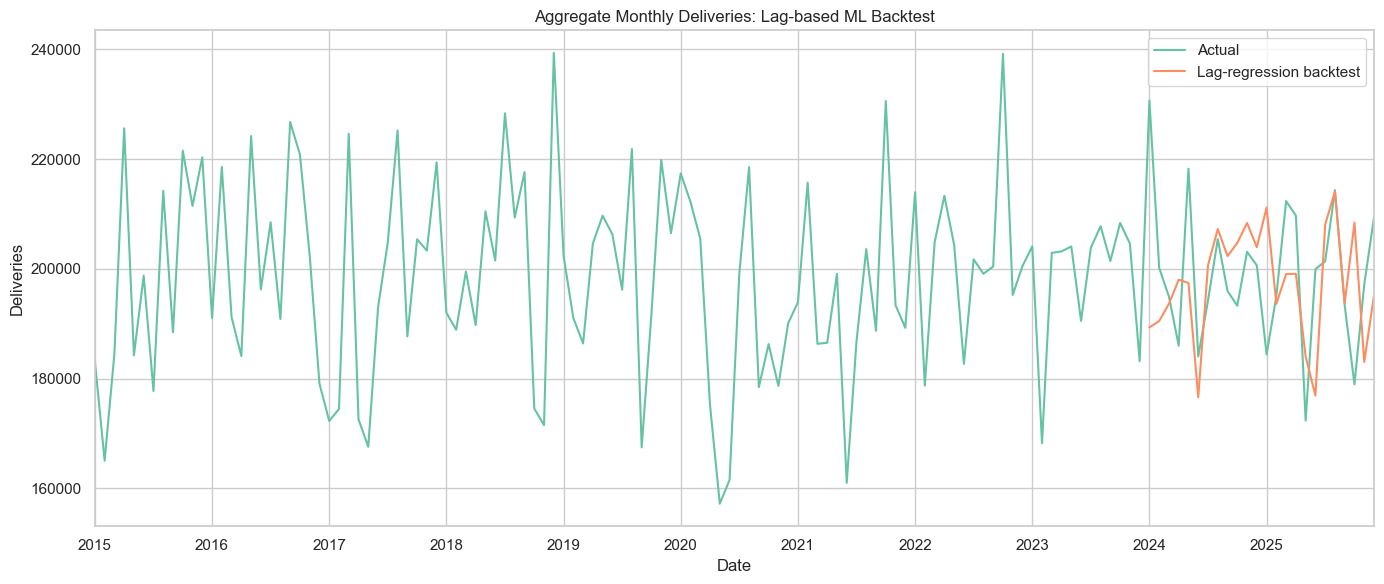

In [23]:
def make_ts_supervised(series, lags=(1, 2, 3, 6, 12)):
    frame = pd.DataFrame({"y": series})
    for lag in lags:
        frame[f"lag_{lag}"] = frame["y"].shift(lag)
    frame["month"] = frame.index.month
    frame["year_index"] = frame.index.year - frame.index.year.min()
    frame["month_sin"] = np.sin(2 * np.pi * frame["month"] / 12)
    frame["month_cos"] = np.cos(2 * np.pi * frame["month"] / 12)
    return frame.dropna()

ts_supervised = make_ts_supervised(ts)
ml_ts_train = ts_supervised.loc[:"2023-12-01"]
ml_ts_test = ts_supervised.loc["2024-01-01":]

ts_features = [c for c in ts_supervised.columns if c != "y"]
ts_model = GradientBoostingRegressor(random_state=42)
ts_model.fit(ml_ts_train[ts_features], ml_ts_train["y"])
ml_ts_preds = pd.Series(ts_model.predict(ml_ts_test[ts_features]), index=ml_ts_test.index)

lag_metrics = pd.DataFrame([{
    "MAE": mean_absolute_error(ml_ts_test["y"], ml_ts_preds),
    "RMSE": rmse(ml_ts_test["y"], ml_ts_preds),
}])
display(lag_metrics)

ax = ts.plot(label="Actual", figsize=(14, 6))
ml_ts_preds.plot(ax=ax, label="Lag-regression backtest")
ax.set_title("Aggregate Monthly Deliveries: Lag-based ML Backtest")
ax.set_ylabel("Deliveries")
ax.legend()
plt.tight_layout()


,Date,Forecast_Deliveries,Lower_CI,Upper_CI
0,2026-01-01,201096.497259,150668.381286,251524.613231
1,2026-02-01,192608.344195,140385.740251,244830.948140
2,2026-03-01,204893.265353,150807.847947,258978.682759
3,2026-04-01,201318.815772,145434.350958,257203.280587
4,2026-05-01,190842.455175,133215.056913,248469.853436
5,2026-06-01,191863.874026,132544.731938,251183.016114
6,2026-07-01,199111.596285,138147.638029,260075.554541
7,2026-08-01,209790.856690,147225.308706,272356.404673
8,2026-09-01,194750.485093,130623.334971,258877.635214
9,2026-10-01,190906.497489,125254.879298,256558.115680


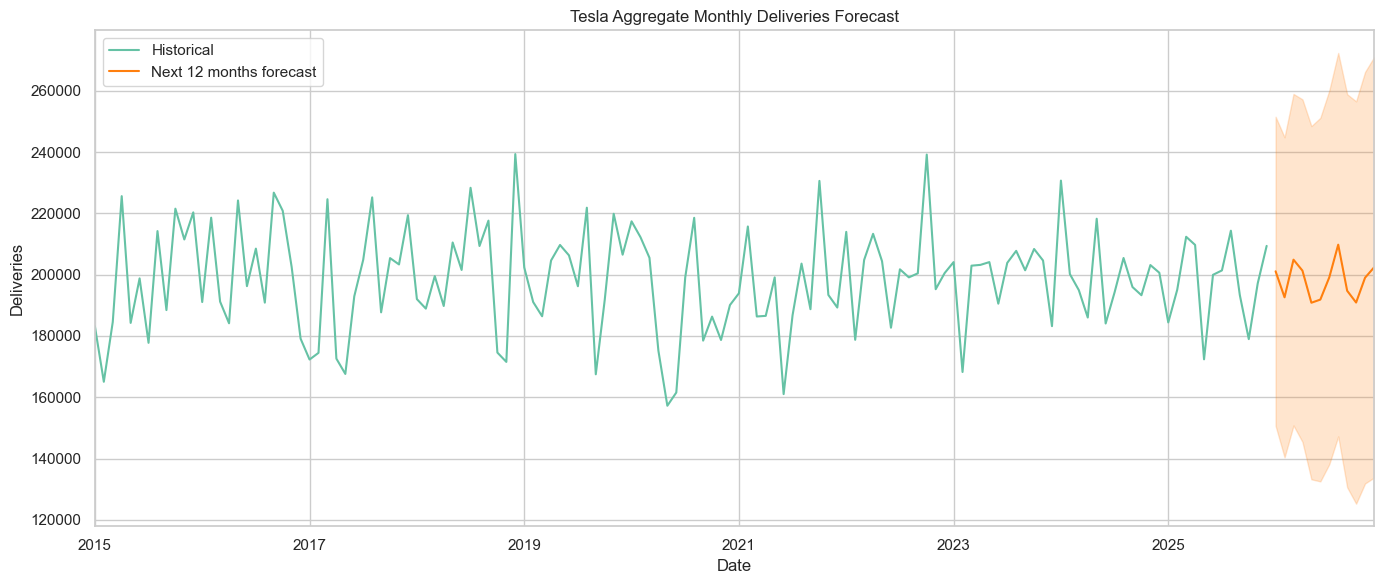

In [24]:
final_sarimax = SARIMAX(
    ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

future_steps = 12
future_forecast = final_sarimax.get_forecast(steps=future_steps)
future_mean = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()

forecast_df = pd.DataFrame({
    "Date": future_mean.index,
    "Forecast_Deliveries": future_mean.values,
    "Lower_CI": future_ci.iloc[:, 0].values,
    "Upper_CI": future_ci.iloc[:, 1].values,
})
display(forecast_df)

ax = ts.plot(label="Historical", figsize=(14, 6))
future_mean.plot(ax=ax, label="Next 12 months forecast", color="tab:orange")
ax.fill_between(
    future_mean.index,
    future_ci.iloc[:, 0],
    future_ci.iloc[:, 1],
    color="tab:orange",
    alpha=0.2
)
ax.set_title("Tesla Aggregate Monthly Deliveries Forecast")
ax.set_ylabel("Deliveries")
ax.legend()
plt.tight_layout()


### Forecast interpretation

Forecasting should be interpreted as a structured estimate, not as certainty. A good forecasting section explains both the signal and the uncertainty:
- the central forecast shows expected delivery levels
- the confidence interval shows plausible variation around that level
- the backtest error tells us how much trust to place in the projected series


## 11. Final Takeaways

This assignment shows three things clearly:

1. **EDA revealed the business structure of the dataset.** Production, seasonality, model mix, and region mix all matter.
2. **Feature engineering improved the learning setup, but leakage had to be handled carefully.** This is one of the most important modeling judgments in the notebook.
3. **Delivery prediction is much stronger than price prediction with the available data.** That is a meaningful analytical result, not a failure.
